### Title:- Build a Multiclass classifier using the CNN model. Use MNIST or any other suitable dataset.

a) Perform Data Pre-processing

b) Define Model and perform training

c) Evaluate Results using confusion matrix.

#### 1) Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


#### 2) Load and Understand Dataset

In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print('Train images shape:', x_train_full.shape)
print('Train labels shape:', y_train_full.shape)
print('Test images shape :', x_test.shape)
print('Test labels shape :', y_test.shape)

num_classes = 10
class_names = [str(i) for i in range(num_classes)]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape : (10000, 28, 28)
Test labels shape : (10000,)


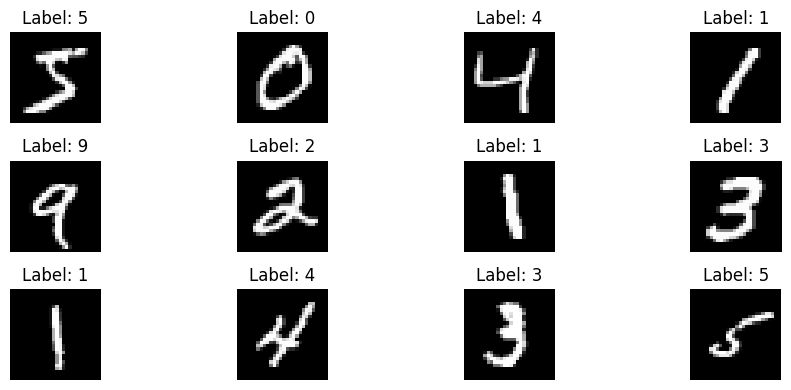

In [ ]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train_full[i], cmap='gray')
    plt.title(f'Label: {y_train_full[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

#### 3) Data Pre-processing

In [ ]:
# Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add channel dimension for CNN: (28, 28) -> (28, 28, 1).................i.e (height,width) --> (height,width,channel(greyscale))
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Split training data into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

# One-hot encode labels
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print('x_train:', x_train.shape)
print('x_val  :', x_val.shape)
print('x_test :', x_test.shape)
print('y_train_cat:', y_train_cat.shape)
print('y_val_cat  :', y_val_cat.shape)
print('y_test_cat :', y_test_cat.shape)

x_train: (54000, 28, 28, 1)
x_val  : (6000, 28, 28, 1)
x_test : (10000, 28, 28, 1)
y_train_cat: (54000, 10)
y_val_cat  : (6000, 10)
y_test_cat : (10000, 10)


#### 4) Build Configurable CNN Model

We will create a reusable function so we can test different hyper-parameter combinations.

In [ ]:
def build_cnn_model(
    input_shape=(28, 28, 1),
    num_classes=10,
    filters=(32, 64),
    kernel_size=3,
    dense_units=128,
    dropout_rate=0.3,
    learning_rate=1e-3,
    optimizer_name='adam'
):
    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    # Add convolution blocks based on number of layers/filters provided
    for f in filters:
        model.add(layers.Conv2D(f, kernel_size=(kernel_size, kernel_size), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation='softmax'))

    if optimizer_name.lower() == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f'Unsupported optimizer: {optimizer_name}')

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

#### 5) Hyper-parameter Experiments

We test multiple combinations of:
- Learning rate
- Filter size (kernel size)
- Number of convolution layers (through filter tuple length)
- Optimizer
- Dropout

In [ ]:
experiment_configs = [
    {
        'name': 'Exp_1_adam_k3_2layers',
        'filters': (32, 64),
        'kernel_size': 3,
        'dropout_rate': 0.30,
        'learning_rate': 1e-3,
        'optimizer_name': 'adam'
    },
    {
        'name': 'Exp_2_adam_k5_2layers',
        'filters': (32, 64),
        'kernel_size': 5,
        'dropout_rate': 0.30,
        'learning_rate': 1e-3,
        'optimizer_name': 'adam'
    },
    {
        'name': 'Exp_3_rmsprop_k3_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.40,
        'learning_rate': 1e-3,
        'optimizer_name': 'rmsprop'
    },
    {
        'name': 'Exp_4_sgd_k3_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.30,
        'learning_rate': 1e-2,
        'optimizer_name': 'sgd'
    },
    {
        'name': 'Exp_5_adam_lowLR_3layers',
        'filters': (32, 64, 128),
        'kernel_size': 3,
        'dropout_rate': 0.25,
        'learning_rate': 5e-4,
        'optimizer_name': 'adam'
    }
]

EPOCHS = 8
BATCH_SIZE = 128

results = []
histories = {}
trained_models = {}

for cfg in experiment_configs:
    print('\n' + '=' * 70)
    print('Running:', cfg['name'])
    print(cfg)

    model = build_cnn_model(
        filters=cfg['filters'],
        kernel_size=cfg['kernel_size'],
        dropout_rate=cfg['dropout_rate'],
        learning_rate=cfg['learning_rate'],
        optimizer_name=cfg['optimizer_name']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        x_train,
        y_train_cat,
        validation_data=(x_val, y_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    val_loss, val_acc = model.evaluate(x_val, y_val_cat, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    results.append({
        'Experiment': cfg['name'],
        'Optimizer': cfg['optimizer_name'],
        'Learning Rate': cfg['learning_rate'],
        'Kernel Size': cfg['kernel_size'],
        'Conv Layers': len(cfg['filters']),
        'Filters': str(cfg['filters']),
        'Dropout': cfg['dropout_rate'],
        'Val Accuracy': val_acc,
        'Test Accuracy': test_acc,
        'Val Loss': val_loss,
        'Test Loss': test_loss
    })

    histories[cfg['name']] = history.history
    trained_models[cfg['name']] = model

    print(f"Validation Accuracy: {val_acc:.4f} | Test Accuracy: {test_acc:.4f}")

results_df = pd.DataFrame(results).sort_values(by='Val Accuracy', ascending=False).reset_index(drop=True)
results_df


Running: Exp_1_adam_k3_2layers
{'name': 'Exp_1_adam_k3_2layers', 'filters': (32, 64), 'kernel_size': 3, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'optimizer_name': 'adam'}
Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.9272 - loss: 0.2415 - val_accuracy: 0.9763 - val_loss: 0.0790
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - accuracy: 0.9787 - loss: 0.0690 - val_accuracy: 0.9812 - val_loss: 0.0696
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - accuracy: 0.9843 - loss: 0.0505 - val_accuracy: 0.9855 - val_loss: 0.0465
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.9884 - loss: 0.0386 - val_accuracy: 0.9858 - val_loss: 0.0463
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9894 - loss: 0.0315 - val_accuracy: 0.9878 - val_loss: 0.0392
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9883 - val_loss: 0.0437
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/st

,Experiment,Optimizer,Learning Rate,Kernel Size,Conv Layers,Filters,Dropout,Val Accuracy,Test Accuracy,Val Loss,Test Loss
0,Exp_2_adam_k5_2layers,adam,0.0010,5,2,"(32, 64)",0.30,0.990833,0.9928,0.034788,0.022308
1,Exp_3_rmsprop_k3_3layers,rmsprop,0.0010,3,3,"(32, 64, 128)",0.40,0.989500,0.9925,0.043011,0.026000
2,Exp_5_adam_lowLR_3layers,adam,0.0005,3,3,"(32, 64, 128)",0.25,0.988833,0.9914,0.036793,0.024138
3,Exp_1_adam_k3_2layers,adam,0.0010,3,2,"(32, 64)",0.30,0.987833,0.9910,0.039167,0.026431
4,Exp_4_sgd_k3_3layers,sgd,0.0100,3,3,"(32, 64, 128)",0.30,0.987500,0.9908,0.047221,0.029247


#### 6) Compare Hyper-parameter Results

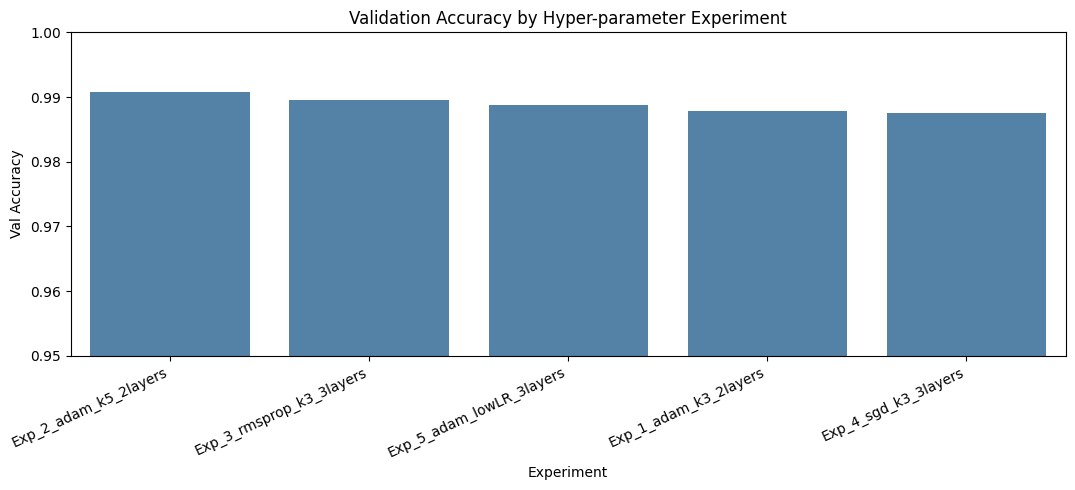

,Experiment,Optimizer,Learning Rate,Kernel Size,Conv Layers,Filters,Dropout,Val Accuracy,Test Accuracy,Val Loss,Test Loss
0,Exp_2_adam_k5_2layers,adam,0.0010,5,2,"(32, 64)",0.30,0.990833,0.9928,0.034788,0.022308
1,Exp_3_rmsprop_k3_3layers,rmsprop,0.0010,3,3,"(32, 64, 128)",0.40,0.989500,0.9925,0.043011,0.026000
2,Exp_5_adam_lowLR_3layers,adam,0.0005,3,3,"(32, 64, 128)",0.25,0.988833,0.9914,0.036793,0.024138
3,Exp_1_adam_k3_2layers,adam,0.0010,3,2,"(32, 64)",0.30,0.987833,0.9910,0.039167,0.026431
4,Exp_4_sgd_k3_3layers,sgd,0.0100,3,3,"(32, 64, 128)",0.30,0.987500,0.9908,0.047221,0.029247


In [ ]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results_df, x='Experiment', y='Val Accuracy', color='steelblue')
plt.xticks(rotation=25, ha='right')
plt.ylim(0.95, 1.0)
plt.title('Validation Accuracy by Hyper-parameter Experiment')
plt.tight_layout()
plt.show()

display(results_df)

In [ ]:
best_experiment = results_df.loc[0, 'Experiment']
best_model = trained_models[best_experiment]

print('Best Experiment:', best_experiment)
print(results_df.loc[0])

Best Experiment: Exp_2_adam_k5_2layers
Experiment       Exp_2_adam_k5_2layers
Optimizer                         adam
Learning Rate                    0.001
Kernel Size                          5
Conv Layers                          2
Filters                       (32, 64)
Dropout                            0.3
Val Accuracy                  0.990833
Test Accuracy                   0.9928
Val Loss                      0.034788
Test Loss                     0.022308
Name: 0, dtype: object


#### 7) Final Evaluation of Best Model (Confusion Matrix)

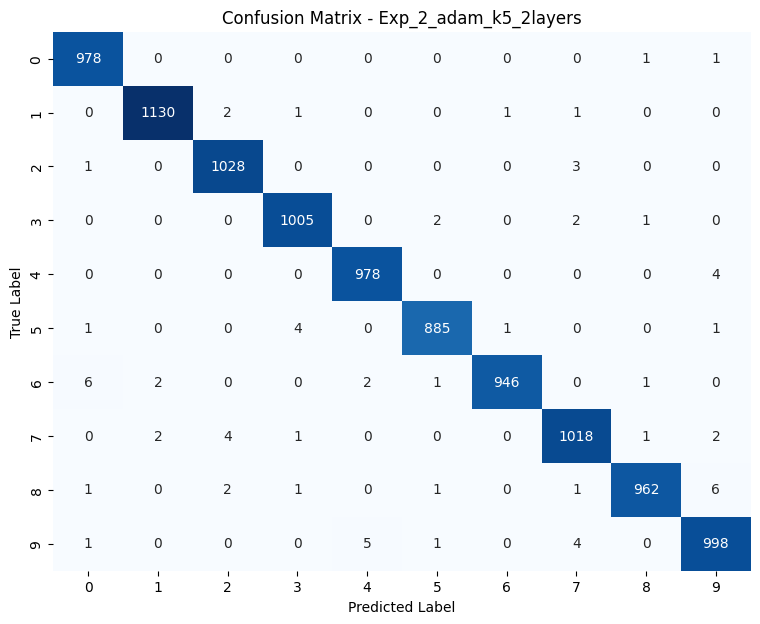

Classification Report:
              precision    recall  f1-score   support

           0     0.9899    0.9980    0.9939       980
           1     0.9965    0.9956    0.9960      1135
           2     0.9923    0.9961    0.9942      1032
           3     0.9931    0.9950    0.9941      1010
           4     0.9929    0.9959    0.9944       982
           5     0.9944    0.9922    0.9933       892
           6     0.9979    0.9875    0.9927       958
           7     0.9893    0.9903    0.9898      1028
           8     0.9959    0.9877    0.9918       974
           9     0.9862    0.9891    0.9876      1009

    accuracy                         0.9928     10000
   macro avg     0.9928    0.9927    0.9928     10000
weighted avg     0.9928    0.9928    0.9928     10000



In [ ]:
# Predictions
y_pred_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_experiment}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('Classification Report:')
print(classification_report(y_test, y_pred, digits=4))

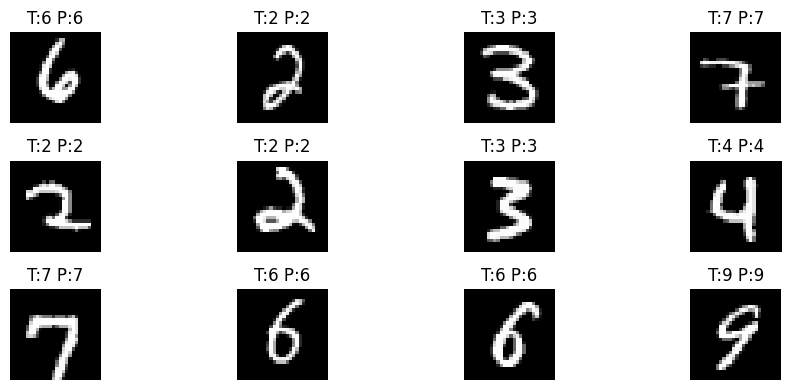

In [ ]:
# Show some sample predictions from the best model
indices = np.random.choice(len(x_test), 12, replace=False)

plt.figure(figsize=(10, 4))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f'T:{y_test[idx]} P:{y_pred[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()